In [75]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

In [73]:
df = pd.read_csv("data/output/srilanka_retail_2020_2026_small.csv")

In [93]:
# Remove rows with missing CustomerID values
df = df.dropna(
    subset=["CustomerID"]
)

# Convert CustomerID to integer type
df["CustomerID"] = df["CustomerID"].astype(int)

# Remove rows with non-positive Quantity values
df = df[
    df["Quantity"] > 0
]

# Remove rows with zero UnitPrice values
df = df[
    df["UnitPrice"] > 0
]


## Feature Engineering

In [76]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"]
)

df["Year"] = df["InvoiceDate"].dt.year

df["Month"] = df["InvoiceDate"].dt.month

df["Month_Name"] = df["InvoiceDate"].dt.month_name()

df["Day"] = df["InvoiceDate"].dt.day_name()

df["Hour"] = df["InvoiceDate"].dt.hour

## Sales Performace Analysis

### District Distribution

In [77]:
geo_data = gpd.read_file("data/geodata/District_geo.json")
geo_data = geo_data[['ADM2_EN', 'geometry']].rename(columns={'ADM2_EN': 'District'})

dis_df = df.groupby('District')['Total_Price_LKR'].sum().sort_values(ascending=False).reset_index()
district = geo_data.merge(dis_df, how='left', left_on='District', right_on='District')

# Drop the first row of the district GeoDataFrame
district = district.iloc[1:]

district["Total_Price_LKR"] = district["Total_Price_LKR"]/1000000  # Convert to millions


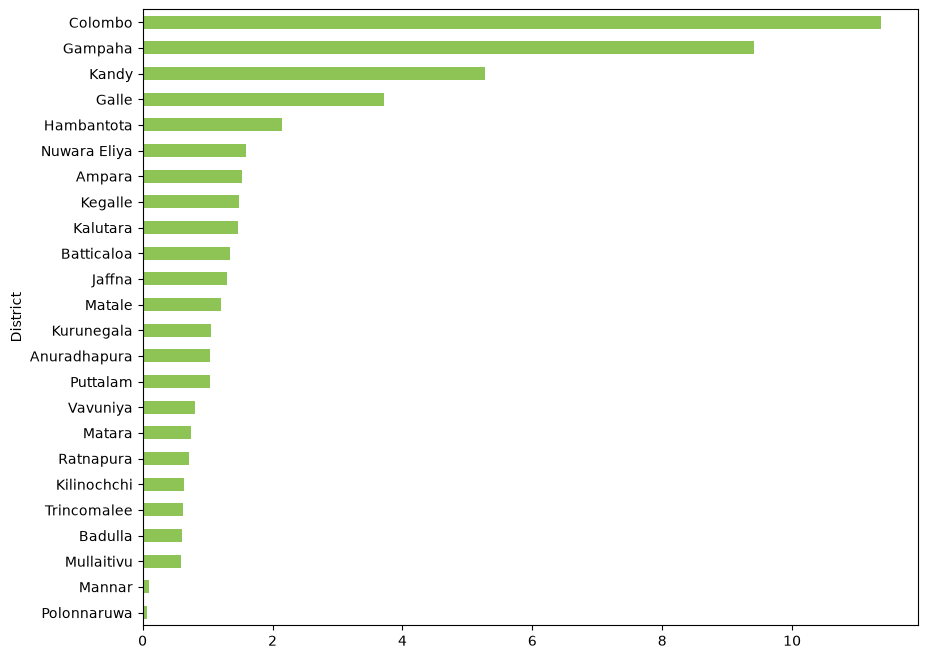

In [82]:
district = district.sort_values(by='Total_Price_LKR', ascending=True)
district.plot(kind="barh", x="District", y="Total_Price_LKR", color='#8ec456', legend=False, figsize=(10, 8))
plt.show()

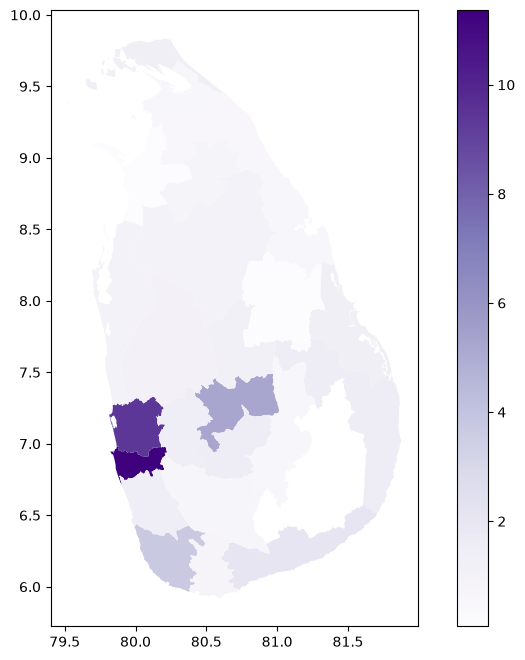

In [47]:
district.plot(column='Total_Price_LKR', cmap='Purples', legend=True, figsize=(10, 8))
plt.show()

### Yearly Trends

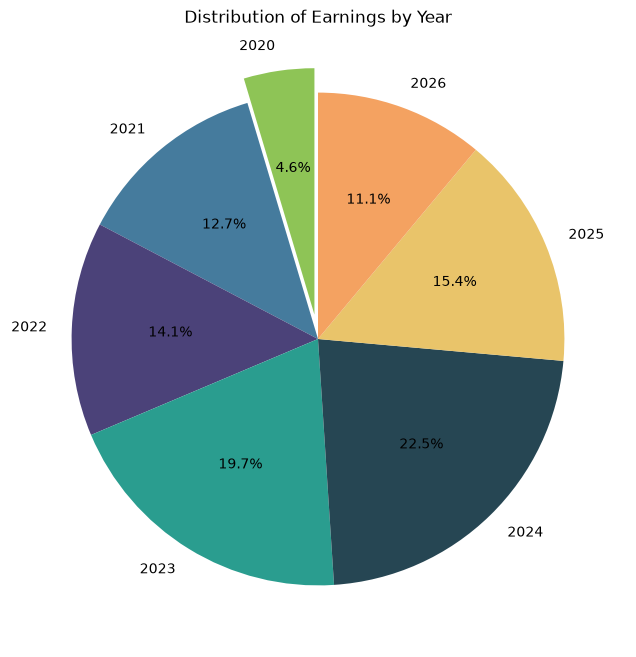

In [ ]:
year_data = df.groupby('Year')['Total_Price_LKR'].sum().reset_index()
year_data['Total_Price_LKR'] = year_data['Total_Price_LKR'] / 1000000

year_price = list(year_data["Total_Price_LKR"])
smallest = year_price.index(min(year_price))

explode = [0] * len(year_price)
explode[smallest] = 0.1  # Explode the smallest slice

year_data.plot.pie(y='Total_Price_LKR', autopct='%1.1f%%',
                    startangle=90, legend=False, figsize=(8, 8)
                    ,labels=year_data['Year'], title='Distribution of Earnings by Year',
                    colors=['#8ec456', '#457b9d', '#4b4279', '#2a9d8f', '#264653', '#e9c46a', '#f4a261'],
                    explode=explode)
plt.show()

### Monthly Trends

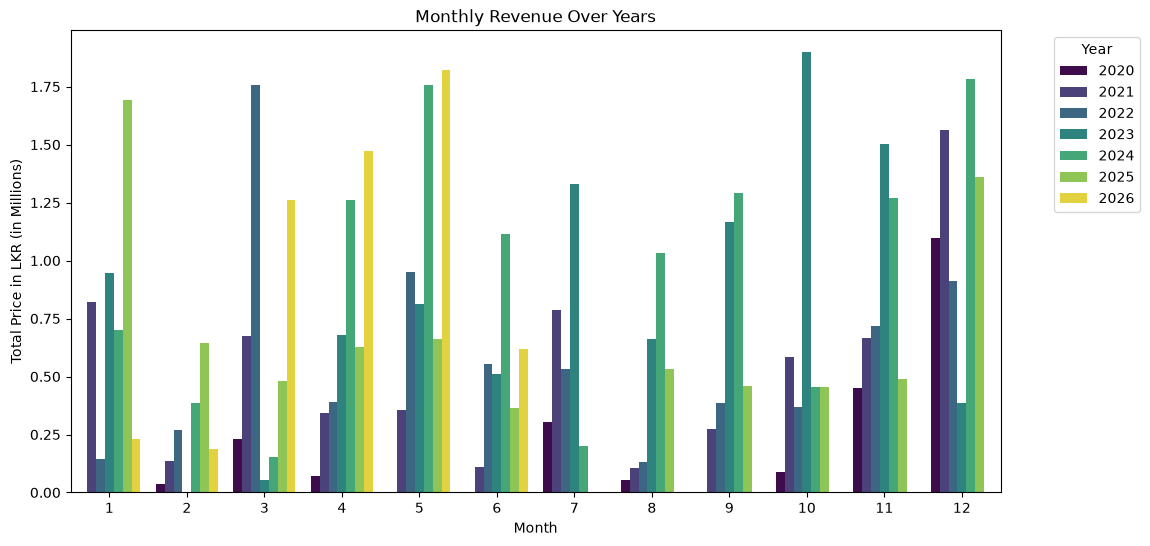

In [91]:
monthly_revenue = df.groupby(['Year', 'Month'])['Total_Price_LKR'].sum().reset_index()
monthly_revenue['Total_Price_LKR'] = monthly_revenue['Total_Price_LKR'] / 1000000

plt.figure(figsize=(12, 6))
sns.barplot(data=monthly_revenue, x='Month', y='Total_Price_LKR', hue='Year', palette='viridis')
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Monthly Revenue Over Years')
plt.xlabel('Month')
plt.ylabel('Total Price in LKR (in Millions)')
plt.show()

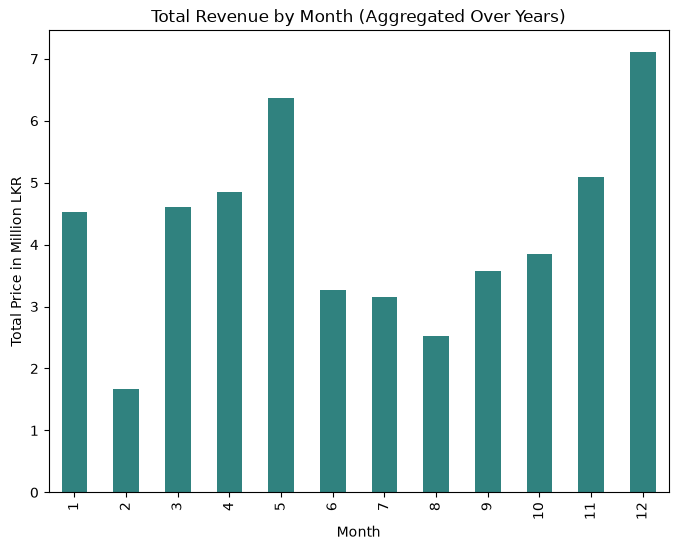

In [133]:
monthly_revenue_only = df.groupby('Month')['Total_Price_LKR'].sum().reset_index()
monthly_revenue_only['Total_Price_LKR'] = monthly_revenue_only['Total_Price_LKR'] / 1000000
monthly_revenue_only.plot(x='Month', y='Total_Price_LKR', kind='bar',
                         title='Total Revenue by Month (Aggregated Over Years)', xlabel='Month',
                            ylabel='Total Price in Million LKR', legend=None, color='#30827f', figsize=(8, 6))
plt.show()

### Daily Trends

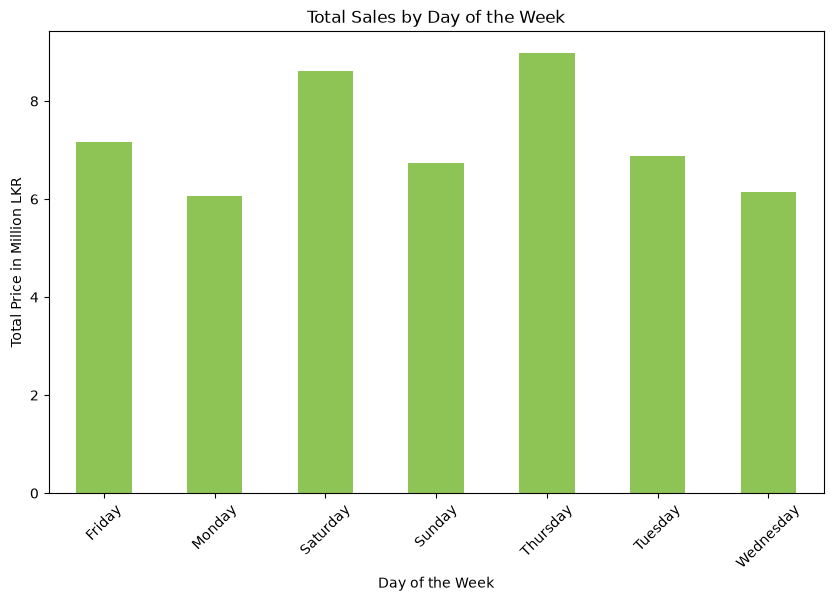

In [130]:
daily_sales = df.groupby("Day")["Total_Price_LKR"].sum().reset_index()

daily_sales["Total_Price_LKR"] = daily_sales["Total_Price_LKR"] / 1000000  # Convert to millions

daily_sales.plot(x="Day", y="Total_Price_LKR", kind="bar", color="#8ec456", legend=None, figsize=(10, 6))
plt.title("Total Sales by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Total Price in Million LKR")
plt.xticks(rotation=45)
plt.show()


### Hourly Trends

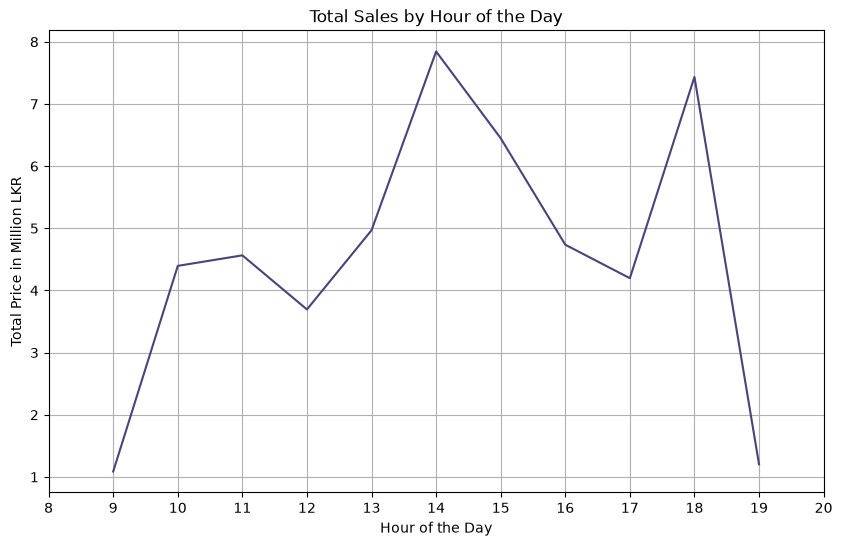

In [140]:
hourly_sales = df.groupby('Hour')['Total_Price_LKR'].sum().reset_index()
hourly_sales['Total_Price_LKR'] = hourly_sales['Total_Price_LKR'] / 1000000  # Convert to millions
hourly_sales.plot(x='Hour', y='Total_Price_LKR', kind='line',
                   title='Total Sales by Hour of the Day', 
                  xlabel='Hour of the Day', ylabel='Total Price in Million LKR', 
                  legend=None, color='#4b4279', figsize=(10, 6))
plt.xticks(range(8, 21))  # Set x-ticks for each hour
plt.grid()
plt.show()  

## Product Analysis

### Best Products by Revenue

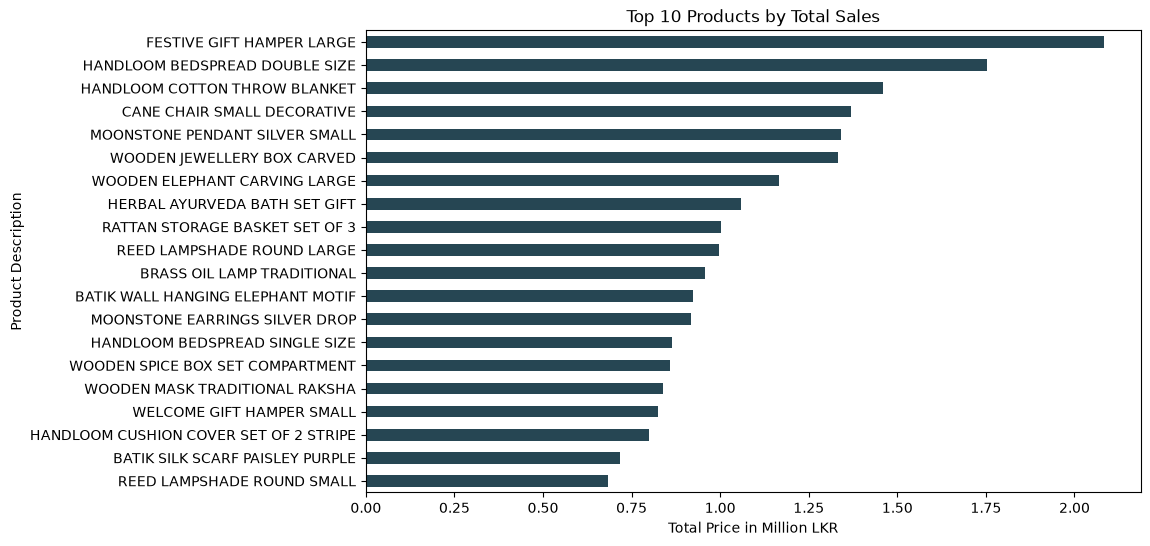

In [154]:
top_products = df.groupby('Description')['Total_Price_LKR'].sum().sort_values(ascending=False).head(20).reset_index()
top_products['Total_Price_LKR'] = top_products['Total_Price_LKR'] / 1000000  # Convert to millions
# Reverse the order of the DataFrame for better visualization in horizontal bar chart
top_products = top_products[::-1].reset_index(drop=True)

top_products.plot(x='Description', y='Total_Price_LKR', kind='barh',
                  title='Top 10 Products by Total Sales',
                  xlabel='Total Price in Million LKR', ylabel='Product Description',
                  legend=None, color='#264653', figsize=(10, 6)) 
plt.show()

### Best Products by Quantity

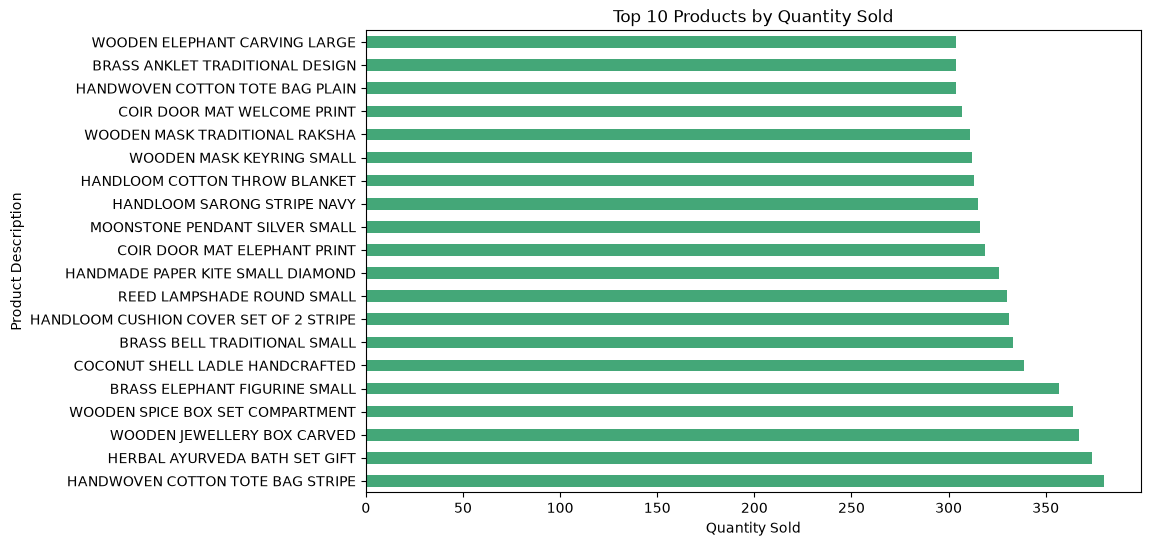

In [156]:
quality_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(20).reset_index()
quality_products.plot(x='Description', y='Quantity', kind='barh',
                  title='Top 10 Products by Quantity Sold',
                  xlabel='Quantity Sold', ylabel='Product Description',
                  legend=None, color='#44a778', figsize=(10, 6))
plt.show()

## Customer Analysis

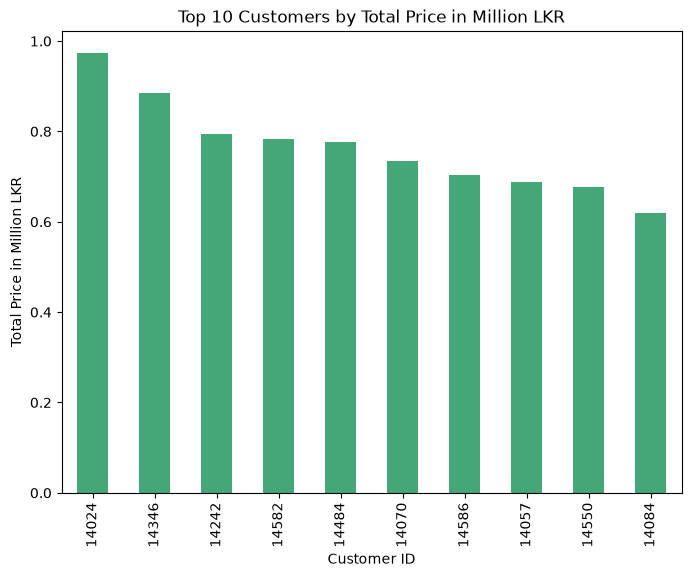

In [84]:
customer_data = df.groupby('CustomerID')['Total_Price_LKR'].sum().reset_index()
top_customers = customer_data.sort_values(by='Total_Price_LKR', ascending=False).head(10)
top_customers['Total_Price_LKR'] = top_customers['Total_Price_LKR'] / 1000000
top_customers.plot(x='CustomerID', y='Total_Price_LKR', kind='bar', 
                   title='Top 10 Customers by Total Price in Million LKR', xlabel='Customer ID',
                     ylabel='Total Price in Million LKR', legend=None, color='#44a778', figsize=(8, 6))

plt.show()